# Import libraries

In [1]:
import json
import numpy as np
import pandas as pd
from helpers.phenotype import attach_populations
from sklearn.decomposition import PCA
from helpers.vizualisation import build_deme_colors, visualize_grid, visualize_pca, visualize_multiple_plots
from helpers.grid import create_grid


# Load params

In [2]:
with open("params.json") as f:
    params = json.load(f)
k           = params["k"]
Ne          = params["Ne"]
M           = params["M"]
n_per_deme  = params["n_per_deme"]
n_loci      = params["n_loci"]
n_mutations = params["n_mutations"]
random_seed = params["random_seed"]
F           = params.get("F", 0.1)

# Load data

In [3]:
fname = f"data/G_k{k}_Ne{Ne}_M{M}_npd{n_per_deme}_nloc{n_loci}_seed{random_seed}.npz"
data  = np.load(fname)
G     = data["G"]

In [4]:
humans = attach_populations(G.shape[1], k, n_per_deme)

In [5]:
G_T = G.T

results = {}
pops = humans['populations'].values  # length 2000

for pop in np.unique(pops):
    mask = pops == pop
    G_pop = G_T[mask]           # subset individuals for this population
    # Pick one random individual per SNP and flip
    idxs = np.random.randint(0, G_pop.shape[0], size=G_pop.shape[1])
    G_pop[idxs, np.arange(G_pop.shape[1])] = 1 - G_pop[idxs, np.arange(G_pop.shape[1])]
    freq = G_pop.mean(axis=0)   # frequency of 1s per SNP
    results[pop] = freq

freq_df = pd.DataFrame(results).T

In [6]:
def generate_genotypes(freq_df, F, n_individuals):
    dfs = []
    for pop, row in freq_df.iterrows():
        q = row.values                       # minor allele freq
        p = 1 - q
        prob_major = p**2 + F * p * q
        prob_het   = 2 * p * q * (1 - F)
        r = np.random.uniform(size=(n_individuals, len(q)))
        genotypes = np.where(r < prob_major, 1,
                    np.where(r < prob_major + prob_het, 0, -1))
        pop_df = pd.DataFrame(genotypes, columns=freq_df.columns)
        pop_df['population'] = pop
        dfs.append(pop_df)
    return pd.concat(dfs, ignore_index=True)

genotype_df = generate_genotypes(freq_df, F, n_per_deme)

In [7]:
# ── MAF, flip, rename, sort ───────────────────────────────────────────────────
def compute_maf(df, snp_cols):
    allele_counts = (df[snp_cols] == -1) * 2 + (df[snp_cols] == 0)
    return allele_counts.mean(axis=0) / 2

def maf_prefix(m):
    if m < 0.01:  return "VR"
    elif m < 0.05: return "R"
    else:          return "C"

snp_cols = [c for c in genotype_df.columns if c != 'population']
maf      = compute_maf(genotype_df, snp_cols)

cols_to_flip = maf[maf > 0.5].index
genotype_df[cols_to_flip] = genotype_df[cols_to_flip] * -1
maf = compute_maf(genotype_df, snp_cols)    # recompute after flip

sorted_cols = maf.sort_values().index
new_columns = {
    col: f"{maf_prefix(maf[col])}_{maf[col]:.2f}_snp_{i+1}"
    for i, col in enumerate(sorted_cols)
}
genotype_df = genotype_df[list(sorted_cols) + ['population']].rename(columns=new_columns)

In [8]:
snp_cols = [col for col in genotype_df.columns if col != 'population']

G_f    = genotype_df[snp_cols]
std    = G_f.std(axis=0); std[std == 0] = 1
G_std  = (G_f - G_f.mean(axis=0)) / std
pca    = PCA(n_components=2)
coords = pca.fit_transform(G_std)

In [9]:
deme_colors = build_deme_colors(k)
sample_demes = np.repeat(np.arange(k*k), n_per_deme)
hap_colors   = [deme_colors[d] for d in sample_demes]

In [10]:
fig_pca  = visualize_pca(hap_colors, coords)

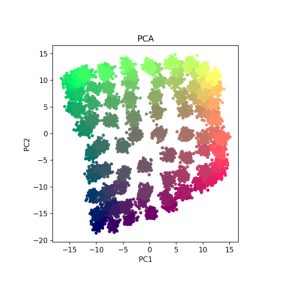

In [11]:
visualize_multiple_plots([fig_pca], figsize_each=(2, 2))

In [12]:
genotype_df

,VR_0.01_snp_1,VR_0.01_snp_2,VR_0.01_snp_3,VR_0.01_snp_4,VR_0.01_snp_5,VR_0.01_snp_6,VR_0.01_snp_7,VR_0.01_snp_8,VR_0.01_snp_9,VR_0.01_snp_10,...,C_0.49_snp_1992,C_0.49_snp_1993,C_0.49_snp_1994,C_0.50_snp_1995,C_0.50_snp_1996,C_0.50_snp_1997,C_0.50_snp_1998,C_0.50_snp_1999,C_0.50_snp_2000,population
0,1,1,1,1,1,1,1,1,1,1,...,1,-1,1,1,-1,-1,1,1,0,1
1,1,1,1,1,1,1,1,1,1,1,...,1,-1,1,1,-1,-1,1,0,1,1
2,1,1,1,1,1,1,1,1,1,1,...,0,-1,-1,-1,-1,-1,1,1,1,1
3,1,1,1,1,1,1,1,1,1,1,...,0,-1,1,1,-1,-1,1,1,0,1
4,1,1,1,1,1,1,1,1,1,1,...,0,-1,-1,1,-1,-1,1,-1,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,1,1,1,1,1,1,...,-1,0,0,-1,1,1,-1,1,1,100
9996,1,1,1,1,1,1,1,1,1,1,...,-1,-1,1,-1,1,1,-1,1,1,100
9997,1,1,1,1,1,1,1,1,1,1,...,-1,-1,1,-1,1,1,-1,1,1,100
9998,1,1,1,1,1,1,1,1,1,1,...,-1,-1,0,-1,0,1,-1,1,1,100


In [13]:
df = genotype_df

gene_cluster
4    1156
3     397
1     314
2     133
Name: count, dtype: int64


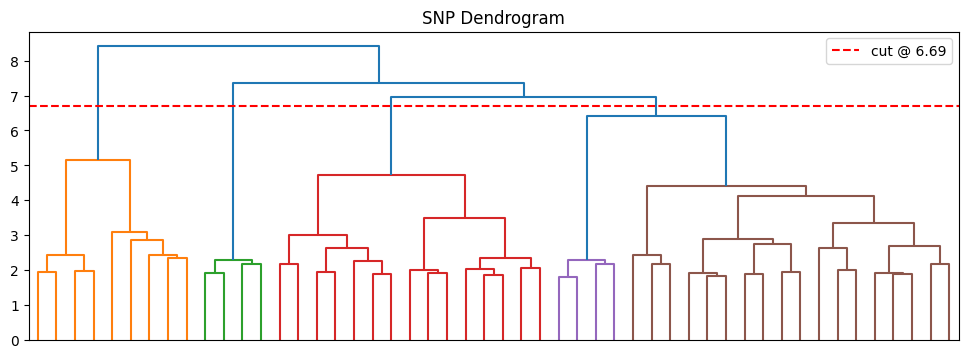

gene_1: 314 SNPs
gene_2: 133 SNPs
gene_3: 397 SNPs
gene_4: 1156 SNPs


In [14]:
import pandas as pd
import numpy as np
from scipy.cluster.hierarchy import linkage, fcluster, dendrogram
from scipy.spatial.distance import pdist
import matplotlib.pyplot as plt

# --- 1. Transpose: SNPs as rows, individuals as columns ---
snp_cols = [c for c in df.columns if c != 'population']
df_snps = df[snp_cols].T  # shape: (2000, 10000)

# --- 2. Compute pairwise distances between SNPs ---
# Correlation-based distance: SNPs with similar population patterns = small distance
distances = pdist(df_snps.values, metric='correlation')

# --- 3. Hierarchical clustering ---
Z = linkage(distances, method='ward')

# --- 4. Cut into 4 clusters ---
labels = fcluster(Z, t=4, criterion='maxclust')  # t=4 → exactly 4 clusters

# --- 5. Assign cluster back to SNP names ---
snp_cluster_map = pd.Series(labels, index=snp_cols, name='gene_cluster')
print(snp_cluster_map.value_counts())  # check cluster sizes

# --- 6. Optional: visualize the dendrogram ---
plt.figure(figsize=(12, 4))
dendrogram(Z, no_labels=True, truncate_mode='lastp', p=50)

# Automatically find the cut height for 4 clusters
# Z[-3, 2] is the height of the 3rd-to-last merge (cutting here gives 4 clusters)
cut_height = (Z[-3, 2] + Z[-4, 2]) / 2  # midpoint between the 3rd and 4th last merges
plt.axhline(y=cut_height, color='r', linestyle='--', label=f'cut @ {cut_height:.2f}')
plt.title("SNP Dendrogram")
plt.legend()
plt.show()

# --- 7. Split df columns into 4 gene dataframes ---
gene_dfs = {}
for gene_id in range(1, 5):
    gene_snps = snp_cluster_map[snp_cluster_map == gene_id].index.tolist()
    gene_dfs[f'gene_{gene_id}'] = df[gene_snps + ['population']]
    print(f"gene_{gene_id}: {len(gene_snps)} SNPs")

In [15]:
from sklearn.preprocessing import MinMaxScaler
from sklearn.decomposition import PCA
import numpy as np

pca = PCA(n_components=3)
scaler = MinMaxScaler(feature_range=(0, 255))

result = {}  # result[population][gene] = rgb_array shape (n_individuals, 3)

populations = df['population'].unique()

for pop in populations:
    result[pop] = {}
    for gene_name, gene_df in gene_dfs.items():
        # Filter to this population
        pop_mask = gene_df['population'] == pop
        snp_data = gene_df.loc[pop_mask].drop(columns='population').values
        
        # PCA → 3 components
        n_samples = snp_data.shape[0]
        n_components = min(3, n_samples, snp_data.shape[1])
        pca = PCA(n_components=n_components)
        reduced = pca.fit_transform(snp_data)  # shape: (n_individuals, 3)
        
        # Normalize each component to [0, 255]
        rgb = scaler.fit_transform(reduced).astype(np.uint8)  # shape: (n_individuals, 3)
        
        result[pop][gene_name] = rgb

# Quick check
for pop in list(result.keys())[:2]:
    for gene in result[pop]:
        print(f"pop={pop}, {gene}: shape={result[pop][gene].shape}, dtype={result[pop][gene].dtype}")

pop=1, gene_1: shape=(100, 3), dtype=uint8
pop=1, gene_2: shape=(100, 3), dtype=uint8
pop=1, gene_3: shape=(100, 3), dtype=uint8
pop=1, gene_4: shape=(100, 3), dtype=uint8
pop=2, gene_1: shape=(100, 3), dtype=uint8
pop=2, gene_2: shape=(100, 3), dtype=uint8
pop=2, gene_3: shape=(100, 3), dtype=uint8
pop=2, gene_4: shape=(100, 3), dtype=uint8


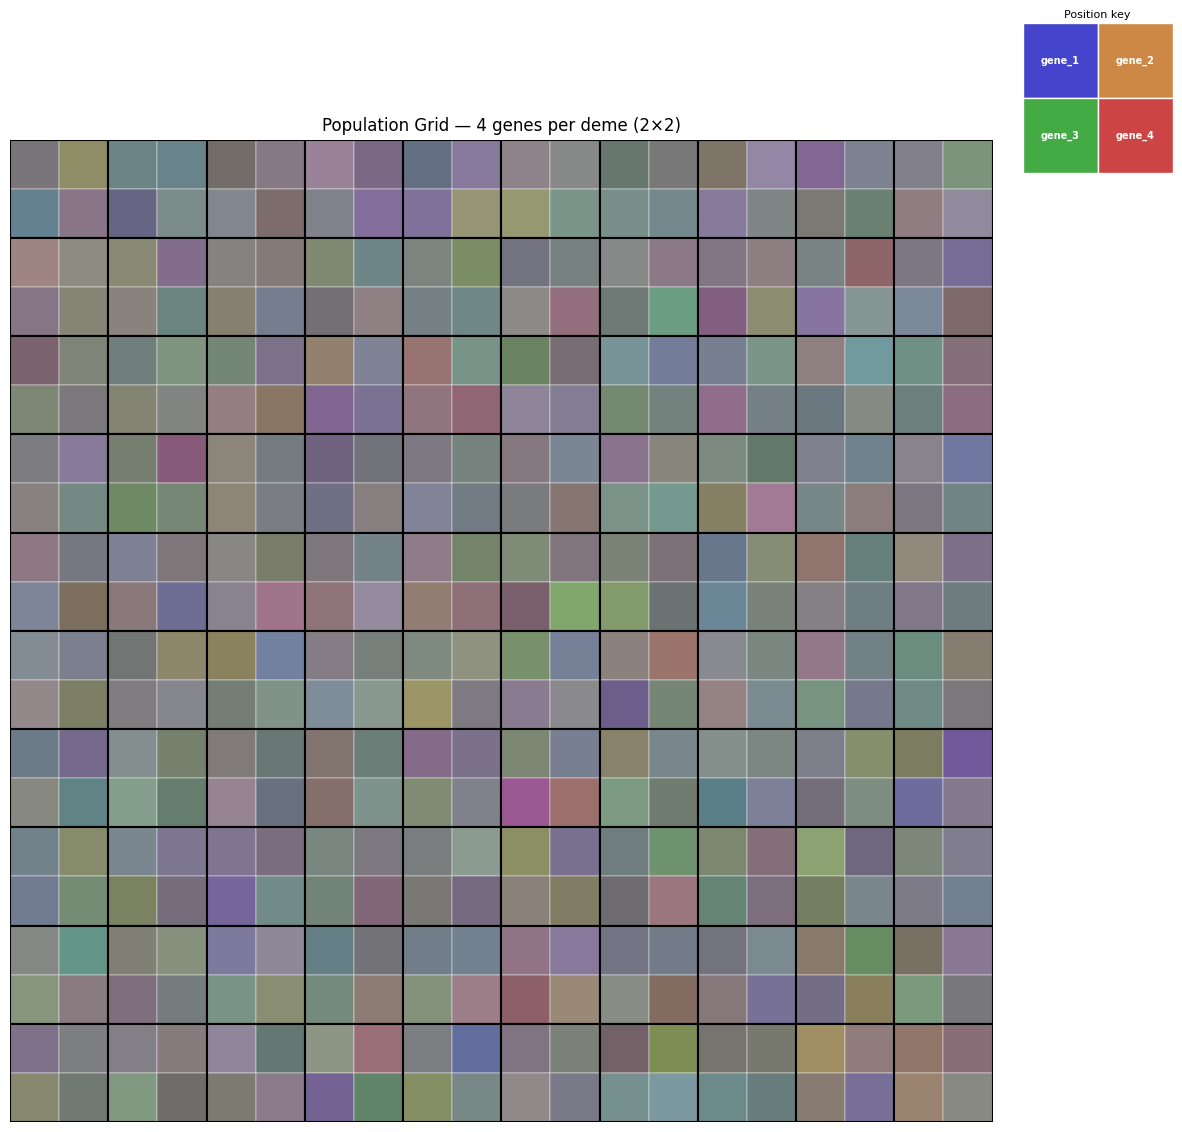

In [17]:
import matplotlib.patches as patches
import matplotlib.pyplot as plt
def plot_gene_grid(result, k, genes_per_deme=4):
    n_cols = int(np.sqrt(genes_per_deme))
    cell_size = 1.0 / n_cols

    fig, ax = plt.subplots(figsize=(k * 1.5, k * 1.5))
    fig.subplots_adjust(right=0.78)  # make room on the right for the inset

    for m in range(k * k):
        pop = m + 1
        r, c = m // k, m % k
        cx, cy = c, k - 1 - r

        gene_colors = []
        for gene_name in [f'gene_{i}' for i in range(1, genes_per_deme + 1)]:
            if pop in result and gene_name in result[pop]:
                mean_rgb = result[pop][gene_name].mean(axis=0) / 255.0
                gene_colors.append(mean_rgb)
            else:
                gene_colors.append([0.5, 0.5, 0.5])

        for idx in range(genes_per_deme):
            sr, sc = idx // n_cols, idx % n_cols
            x = cx + sc * cell_size
            y = cy + (n_cols - 1 - sr) * cell_size
            rect = patches.Rectangle(
                (x, y), cell_size, cell_size,
                color=gene_colors[idx], ec='white', lw=0.3
            )
            ax.add_patch(rect)

        deme_border = patches.Rectangle(
            (cx, cy), 1, 1,
            fill=False, ec='black', lw=1.5
        )
        ax.add_patch(deme_border)

    ax.set_xlim(0, k)
    ax.set_ylim(0, k)
    ax.set_aspect('equal')
    ax.axis('off')
    ax.set_title(f"Population Grid — {genes_per_deme} genes per deme ({n_cols}×{n_cols})", fontsize=12)

    # Inset positioned in the right margin (outside the main axes)
    inset = fig.add_axes([0.80, 0.80, 0.10, 0.10])  # [left, bottom, width, height] in figure coords

    gene_labels = [f'gene_{i+1}' for i in range(genes_per_deme)]
    colors = ['#4444cc', '#cc8844', '#44aa44', '#cc4444']

    for idx in range(genes_per_deme):
        sr, sc = idx // n_cols, idx % n_cols
        inset.add_patch(patches.Rectangle(
            (sc, n_cols - 1 - sr), 1, 1,
            color=colors[idx], ec='white', lw=1
        ))
        inset.text(sc + 0.5, n_cols - 1 - sr + 0.5, gene_labels[idx],
                   ha='center', va='center', fontsize=7, color='white', fontweight='bold')

    inset.set_xlim(0, n_cols)
    inset.set_ylim(0, n_cols)
    inset.set_aspect('equal')
    inset.axis('off')
    inset.set_title('Position key', fontsize=8, pad=4)

    plt.show()

plot_gene_grid(result, k=10)

In [18]:
# snp_cluster_map is a Series: index=snp_name, value=cluster_id (1..n_genes)
# genotype_df has SNP columns + 'population'

n_genes = snp_cluster_map.nunique()

gene_dfs = {}
for gene_id in range(1, n_genes + 1):
    gene_snps = snp_cluster_map[snp_cluster_map == gene_id].index.tolist()
    # Only keep SNPs that actually exist in genotype_df
    gene_snps = [s for s in gene_snps if s in genotype_df.columns]
    gene_dfs[f'gene_{gene_id}'] = genotype_df[gene_snps + ['population']]
    print(f"gene_{gene_id}: {len(gene_snps)} SNPs")

gene_1: 314 SNPs
gene_2: 133 SNPs
gene_3: 397 SNPs
gene_4: 1156 SNPs


In [19]:
gene_dfs['gene_1']

,R_0.01_snp_203,R_0.01_snp_402,R_0.01_snp_508,R_0.01_snp_511,R_0.01_snp_514,R_0.01_snp_517,R_0.01_snp_518,R_0.01_snp_529,R_0.01_snp_538,R_0.01_snp_560,...,C_0.47_snp_1968,C_0.47_snp_1971,C_0.48_snp_1975,C_0.48_snp_1977,C_0.48_snp_1978,C_0.49_snp_1984,C_0.49_snp_1985,C_0.49_snp_1992,C_0.50_snp_1997,population
0,1,1,1,1,1,1,1,1,1,1,...,-1,-1,0,-1,-1,-1,0,1,-1,1
1,1,1,1,1,1,1,1,1,1,1,...,0,-1,-1,-1,-1,-1,-1,1,-1,1
2,1,1,1,1,1,1,1,1,1,1,...,-1,0,-1,-1,-1,-1,-1,0,-1,1
3,1,1,1,1,1,0,1,1,1,1,...,0,-1,-1,-1,-1,-1,-1,0,-1,1
4,1,1,1,1,1,1,1,1,1,1,...,1,-1,-1,-1,-1,-1,-1,0,-1,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9995,1,1,1,1,1,1,1,1,1,1,...,1,0,1,-1,1,1,1,-1,1,100
9996,1,1,1,1,1,0,1,1,1,1,...,1,-1,1,-1,1,1,1,-1,1,100
9997,1,1,1,1,1,1,1,1,1,1,...,1,-1,1,-1,1,1,1,-1,1,100
9998,1,1,1,1,1,1,1,1,1,1,...,1,-1,1,-1,-1,1,1,-1,1,100


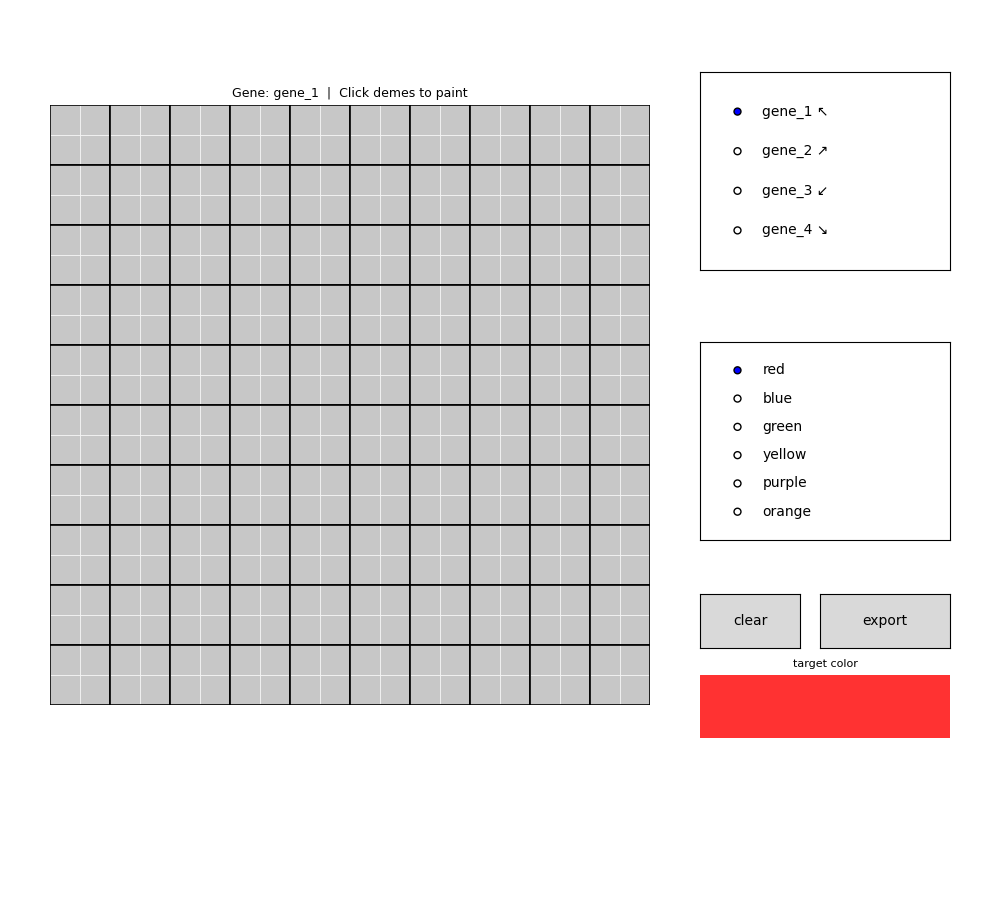

In [20]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
from matplotlib.widgets import Button, RadioButtons
import numpy as np

%matplotlib widget

K = 10
CELL = 1.0
HALF = CELL / 2
GENE_POS = {'gene_1': (0,1), 'gene_2': (1,1), 'gene_3': (0,0), 'gene_4': (1,0)}
GENE_COLORS_DEFAULT = {'gene_1': [0.6,0.6,0.6], 'gene_2': [0.6,0.6,0.6],
                       'gene_3': [0.6,0.6,0.6], 'gene_4': [0.6,0.6,0.6]}

# ── State ────────────────────────────────────────────────────────────────────
selections = {}       # {pop: {gene: np.array([R,G,B])}}
selected_gene = ['gene_1']
target_color = [[255, 50, 50]]   # mutable list so closures can update it

COLOR_PRESETS = {
    'red':    np.array([220,  50,  50]),
    'blue':   np.array([ 50,  50, 220]),
    'green':  np.array([ 50, 180,  50]),
    'yellow': np.array([220, 200,  50]),
    'purple': np.array([150,  50, 200]),
    'orange': np.array([220, 130,  50]),
}

# ── Figure layout ─────────────────────────────────────────────────────────────
fig = plt.figure(figsize=(10, 9))
ax_grid   = fig.add_axes([0.05, 0.15, 0.60, 0.80])   # main grid
ax_gene   = fig.add_axes([0.70, 0.70, 0.25, 0.22])   # gene selector
ax_color  = fig.add_axes([0.70, 0.40, 0.25, 0.22])   # color selector
ax_clear  = fig.add_axes([0.70, 0.28, 0.10, 0.06])   # clear button
ax_export = fig.add_axes([0.82, 0.28, 0.13, 0.06])   # export button
ax_preview= fig.add_axes([0.70, 0.18, 0.25, 0.07])   # color preview

ax_grid.set_xlim(0, K)
ax_grid.set_ylim(0, K)
ax_grid.set_aspect('equal')
ax_grid.axis('off')
ax_grid.set_title('Click demes to paint selection', fontsize=10)

# ── Draw grid ─────────────────────────────────────────────────────────────────
sub_rects = {}  # {(pop, gene): Rectangle patch}

def draw_grid():
    ax_grid.clear()
    ax_grid.set_xlim(0, K)
    ax_grid.set_ylim(0, K)
    ax_grid.set_aspect('equal')
    ax_grid.axis('off')
    ax_grid.set_title(f'Gene: {selected_gene[0]}  |  Click demes to paint', fontsize=9)

    for m in range(K * K):
        pop = m + 1
        r, c = m // K, m % K
        cx, cy = c, K - 1 - r

        for gene, (gsc, gsr) in GENE_POS.items():
            x = cx + gsc * HALF
            y = cy + gsr * HALF
            if pop in selections and gene in selections[pop]:
                color = selections[pop][gene] / 255.0
            else:
                color = [0.78, 0.78, 0.78]
            rect = patches.Rectangle((x, y), HALF, HALF,
                                      color=color, ec='white', lw=0.4)
            ax_grid.add_patch(rect)

        # Deme border
        ax_grid.add_patch(patches.Rectangle((cx, cy), 1, 1,
                          fill=False, ec='black', lw=1.2))

    fig.canvas.draw_idle()

# ── Widgets ───────────────────────────────────────────────────────────────────
radio_gene = RadioButtons(ax_gene,
    ['gene_1 ↖', 'gene_2 ↗', 'gene_3 ↙', 'gene_4 ↘'], active=0)

radio_color = RadioButtons(ax_color,
    list(COLOR_PRESETS.keys()), active=0)

preview_rect = patches.Rectangle((0,0), 1, 1,
    color=np.array(target_color[0])/255, transform=ax_preview.transAxes)
ax_preview.add_patch(preview_rect)
ax_preview.axis('off')
ax_preview.set_title('target color', fontsize=8)

btn_clear  = Button(ax_clear,  'clear')
btn_export = Button(ax_export, 'export')

# ── Callbacks ─────────────────────────────────────────────────────────────────
def on_gene_select(label):
    selected_gene[0] = label.split(' ')[0]
    draw_grid()

def on_color_select(label):
    target_color[0] = COLOR_PRESETS[label].copy()
    preview_rect.set_facecolor(target_color[0] / 255)
    fig.canvas.draw_idle()

def on_click(event):
    if event.inaxes != ax_grid:
        return
    c = int(event.xdata)
    r = int(event.ydata)
    if not (0 <= c < K and 0 <= r < K):
        return
    pop = (K - 1 - r) * K + c + 1
    gene = selected_gene[0]

    if pop not in selections:
        selections[pop] = {}

    if gene in selections[pop]:
        del selections[pop][gene]           # toggle off
        if not selections[pop]:
            del selections[pop]
    else:
        selections[pop][gene] = target_color[0].copy()

    draw_grid()
    print_selections()

def on_clear(event):
    selections.clear()
    draw_grid()

def on_export(event):
    export_dict = {}
    for pop, genes in sorted(selections.items()):
        export_dict[str(pop)] = {
            gene: rgb.tolist()
            for gene, rgb in genes.items()
        }
    with open('selection_targets.json', 'w') as f:
        json.dump(export_dict, f, indent=2)
    print(f"Saved {len(export_dict)} demes to selection_targets.json")

def print_selections():
    print({pop: {g: list(rgb) for g, rgb in genes.items()}
           for pop, genes in selections.items()})

radio_gene.on_clicked(on_gene_select)
radio_color.on_clicked(on_color_select)
fig.canvas.mpl_connect('button_press_event', on_click)
btn_clear.on_clicked(on_clear)
btn_export.on_clicked(on_export)

draw_grid()
plt.show()

gene_1: explained variance = [0.184 0.079 0.039]
gene_2: explained variance = [0.302 0.045 0.04 ]
gene_3: explained variance = [0.154 0.065 0.044]
gene_4: explained variance = [0.112 0.038 0.032]
State built.
Example: pop=1, gene_1, hap1 shape = (100, 314)
Loaded selection targets for 20 demes:
  pop 1 · gene_1 → RGB(np.int64(220), np.int64(50), np.int64(50))
  pop 2 · gene_1 → RGB(np.int64(220), np.int64(50), np.int64(50))
  pop 3 · gene_1 → RGB(np.int64(220), np.int64(50), np.int64(50))
  pop 4 · gene_1 → RGB(np.int64(220), np.int64(130), np.int64(50))
  pop 5 · gene_1 → RGB(np.int64(220), np.int64(130), np.int64(50))
  pop 6 · gene_1 → RGB(np.int64(220), np.int64(130), np.int64(50))
  pop 7 · gene_1 → RGB(np.int64(220), np.int64(130), np.int64(50))
  pop 8 · gene_1 → RGB(np.int64(150), np.int64(50), np.int64(200))
  pop 9 · gene_1 → RGB(np.int64(150), np.int64(50), np.int64(200))
  pop 10 · gene_1 → RGB(np.int64(150), np.int64(50), np.int64(200))
  pop 11 · gene_1 → RGB(np.int64(220

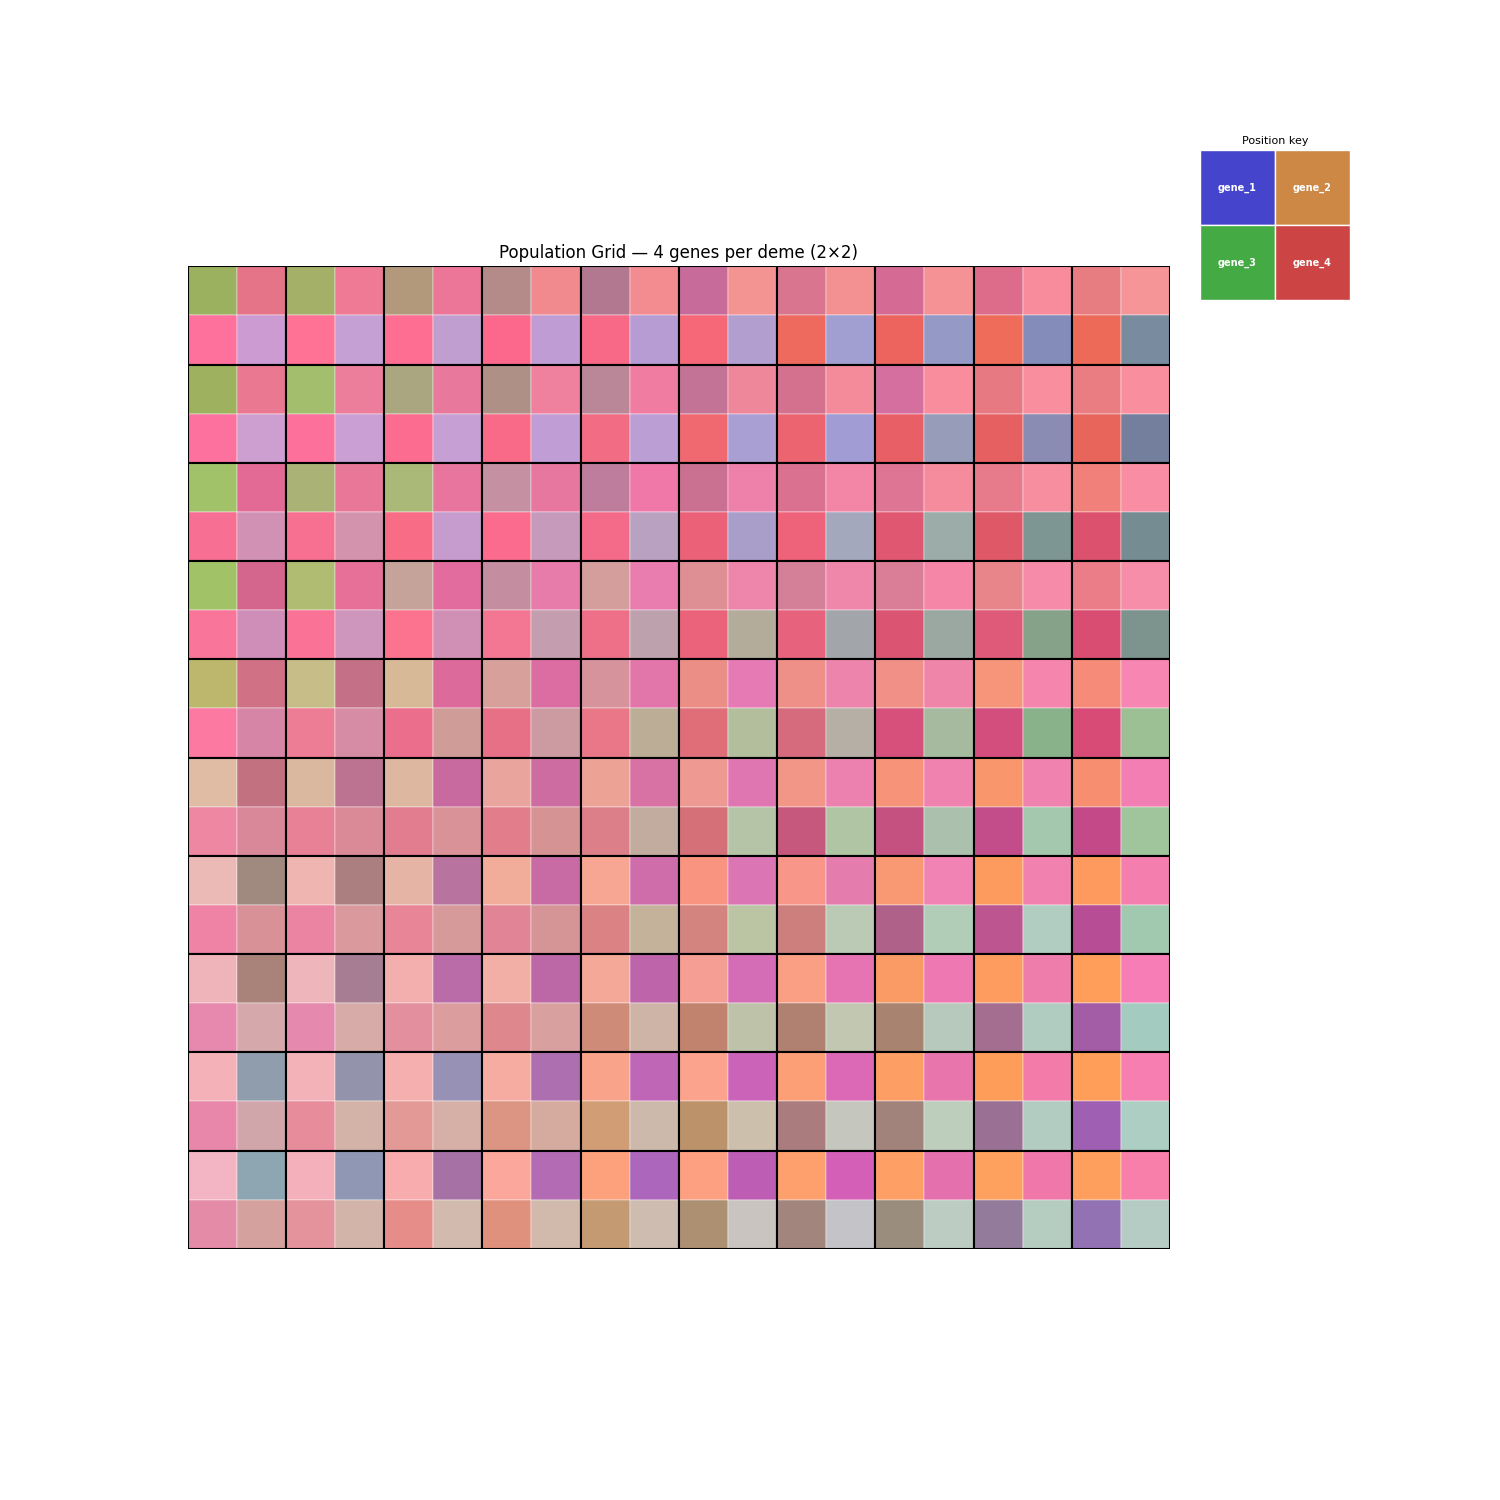

In [25]:
import numpy as np
import pandas as pd
import json
from sklearn.decomposition import PCA
from sklearn.preprocessing import MinMaxScaler

# ── 1. Fix PCA per gene at generation 0 ──────────────────────────────────────
gene_pca    = {}
gene_scaler = {}

for gene_name, gene_df in gene_dfs.items():
    snp_data = gene_df.drop(columns='population').values
    
    pca = PCA(n_components=3)
    reduced = pca.fit_transform(snp_data)
    
    scaler = MinMaxScaler(feature_range=(0, 255))
    scaler.fit(reduced)
    
    gene_pca[gene_name]    = pca
    gene_scaler[gene_name] = scaler
    print(f"{gene_name}: explained variance = {pca.explained_variance_ratio_.round(3)}")


# ── 2. Diploid representation ─────────────────────────────────────────────────
def genotype_to_haplotypes(genotype_array):
    n_ind, n_snps = genotype_array.shape
    hap1 = np.zeros((n_ind, n_snps), dtype=np.int8)
    hap2 = np.zeros((n_ind, n_snps), dtype=np.int8)
    
    alt_alt = (genotype_array == 1)
    hap1[alt_alt] = 1
    hap2[alt_alt] = 1
    
    het = (genotype_array == 0)
    rand_phase = np.random.randint(0, 2, size=(n_ind, n_snps)).astype(np.int8)
    hap1[het] = rand_phase[het]
    hap2[het] = 1 - rand_phase[het]
    
    return hap1, hap2


# ── 3. Build population state ─────────────────────────────────────────────────
state = {}
for pop in range(1, 101):
    state[pop] = {}
    for gene_name, gene_df in gene_dfs.items():
        pop_snps = gene_df[gene_df['population'] == pop].drop(columns='population').values
        hap1, hap2 = genotype_to_haplotypes(pop_snps)
        state[pop][gene_name] = {'hap1': hap1, 'hap2': hap2}

print("State built.")
print(f"Example: pop=1, gene_1, hap1 shape = {state[1]['gene_1']['hap1'].shape}")


# ── 4. state -> RGB (fixed PCA) ───────────────────────────────────────────────
def state_to_rgb(state, gene_pca, gene_scaler):
    result = {}
    for pop in state:
        result[pop] = {}
        for gene_name in state[pop]:
            hap1 = state[pop][gene_name]['hap1']
            hap2 = state[pop][gene_name]['hap2']
            genotype = (hap1.astype(float) + hap2.astype(float)) / 2
            reduced  = gene_pca[gene_name].transform(genotype)
            rgb      = gene_scaler[gene_name].transform(reduced)
            rgb      = np.clip(rgb, 0, 255).astype(np.uint8)
            result[pop][gene_name] = rgb
    return result


# ── 5. Recombination ──────────────────────────────────────────────────────────
def recombine(hap1, hap2, recomb_rate=0.01):
    if np.random.random() < recomb_rate:
        point = np.random.randint(1, len(hap1))
        new_hap1 = np.concatenate([hap1[:point], hap2[point:]])
        new_hap2 = np.concatenate([hap2[:point], hap1[point:]])
        return new_hap1, new_hap2
    return hap1.copy(), hap2.copy()


# ── 6. Fitness ────────────────────────────────────────────────────────────────
MAX_DIST = 255 * np.sqrt(3)

def compute_fitness(hap1, hap2, gene_name, target_rgb, gene_pca, gene_scaler, s=0.3):
    genotype = (hap1.astype(float) + hap2.astype(float)) / 2
    reduced  = gene_pca[gene_name].transform(genotype)
    rgb      = gene_scaler[gene_name].transform(reduced)
    rgb      = np.clip(rgb, 0, 255)
    dist     = np.linalg.norm(rgb - target_rgb, axis=1)
    fitness  = 1 + s * (1 - dist / MAX_DIST)
    return fitness


def wright_fisher_step(pop_state, gene_pca, gene_scaler,
                       selection_targets=None, s=0.3, recomb_rate=0.01):
    n_ind = next(iter(pop_state.values()))['hap1'].shape[0]
    new_state = {}
    
    # Compute neutral fitness (uniform) once
    neutral_fitness = np.ones(n_ind) / n_ind

    for gene_name in pop_state:
        hap1 = pop_state[gene_name]['hap1']
        hap2 = pop_state[gene_name]['hap2']
        new_hap1 = np.empty_like(hap1)
        new_hap2 = np.empty_like(hap2)

        # Only apply selection fitness to the targeted gene
        if selection_targets and gene_name in selection_targets:
            fitness = compute_fitness(
                hap1, hap2, gene_name,
                selection_targets[gene_name],
                gene_pca, gene_scaler, s
            )
            fitness /= fitness.sum()
        else:
            fitness = neutral_fitness  # pure drift for unselected genes

        parents1 = np.random.choice(n_ind, size=n_ind, replace=True, p=fitness)
        parents2 = np.random.choice(n_ind, size=n_ind, replace=True, p=fitness)

        for i in range(n_ind):
            p1_h1, _ = recombine(hap1[parents1[i]], hap2[parents1[i]], recomb_rate)
            p2_h1, _ = recombine(hap1[parents2[i]], hap2[parents2[i]], recomb_rate)
            new_hap1[i] = p1_h1
            new_hap2[i] = p2_h1

        new_state[gene_name] = {'hap1': new_hap1, 'hap2': new_hap2}

    return new_state


# ── 8. Migration ──────────────────────────────────────────────────────────────
def migrate(state, neighbors, migration_rate=0.05):
    new_state = {pop: {g: {'hap1': state[pop][g]['hap1'].copy(),
                            'hap2': state[pop][g]['hap2'].copy()}
                        for g in state[pop]}
                 for pop in state}

    visited = set()
    for pop, nbrs in neighbors.items():
        for nbr in nbrs:
            if (nbr, pop) in visited:
                continue
            visited.add((pop, nbr))

            n_ind      = next(iter(state[pop].values()))['hap1'].shape[0]
            n_migrants = max(1, int(migration_rate * n_ind))
            migrants_from_pop = np.random.choice(n_ind, size=n_migrants, replace=False)
            migrants_from_nbr = np.random.choice(n_ind, size=n_migrants, replace=False)

            for gene_name in state[pop]:
                h1_pop = new_state[pop][gene_name]['hap1'][migrants_from_pop].copy()
                h2_pop = new_state[pop][gene_name]['hap2'][migrants_from_pop].copy()
                h1_nbr = new_state[nbr][gene_name]['hap1'][migrants_from_nbr].copy()
                h2_nbr = new_state[nbr][gene_name]['hap2'][migrants_from_nbr].copy()

                new_state[pop][gene_name]['hap1'][migrants_from_pop] = h1_nbr
                new_state[pop][gene_name]['hap2'][migrants_from_pop] = h2_nbr
                new_state[nbr][gene_name]['hap1'][migrants_from_nbr] = h1_pop
                new_state[nbr][gene_name]['hap2'][migrants_from_nbr] = h2_pop

    return new_state


# ── 9. Simulation loop ────────────────────────────────────────────────────────
def simulate(state, neighbors, gene_pca, gene_scaler,
             n_generations=20,
             selection_targets=None,
             s=0.3,
             recomb_rate=0.01,
             migration_rate=0.05,
             snapshot_every=1):
    snapshots = []
    current_state = state

    for gen in range(n_generations):
        current_state = migrate(current_state, neighbors, migration_rate)

        new_state = {}
        for pop in current_state:
            pop_selection = selection_targets.get(pop, None) if selection_targets else None
            new_state[pop] = wright_fisher_step(
                current_state[pop], gene_pca, gene_scaler,
                selection_targets=pop_selection, s=s, recomb_rate=recomb_rate
            )
        current_state = new_state

        if gen % snapshot_every == 0:
            rgb = state_to_rgb(current_state, gene_pca, gene_scaler)
            snapshots.append((gen, rgb))
            print(f"Generation {gen+1}/{n_generations} done")

    return snapshots, current_state


# ── 10. Load selection targets from painter ───────────────────────────────────
with open('selection_targets.json') as f:
    raw = json.load(f)

selection_targets = {
    int(pop): {gene: np.array(rgb) for gene, rgb in genes.items()}
    for pop, genes in raw.items()
}
print(f"Loaded selection targets for {len(selection_targets)} demes:")
for pop, genes in selection_targets.items():
    for gene, rgb in genes.items():
        print(f"  pop {pop} · {gene} → RGB{tuple(rgb)}")


# ── 11. Run ───────────────────────────────────────────────────────────────────
grid, neighbors = create_grid(k=10)
neighbors_1idx  = {pop + 1: [nbr + 1 for nbr in nbrs] for pop, nbrs in neighbors.items()}

snapshots, final_state = simulate(
    state, neighbors_1idx, gene_pca, gene_scaler,
    n_generations=100,
    selection_targets=selection_targets,
    s=0.3,
    recomb_rate=0.01,
    migration_rate=0,  # was 0.05 — much lower to preserve spatial structure
    snapshot_every=1
)
gen, rgb = snapshots[-1]
plot_gene_grid(rgb, k=10)